<a href="https://colab.research.google.com/github/angelfrancomorales/INFO648/blob/main/Problem_Set_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Random Forests, ROC Curves, and Feature Importance**

**Part 1: Data Preparation**

In [13]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

df = pd.read_csv('churn_synthetic_600_new.csv')
df.head()

,CustomerID,Churn,TenureMonths,MonthlyCharge,ContractType,PaymentMethod,SupportCalls
0,C0001,1,23,77.81,Month-to-Month,Credit Card,1
1,C0002,0,33,69.65,One-Year,Credit Card,1
2,C0003,1,22,64.27,Month-to-Month,Electronic Check,2
3,C0004,1,4,66.30,Month-to-Month,Credit Card,3
4,C0005,0,2,60.82,One-Year,Bank Transfer,1


In [14]:
print(df.dtypes)
print(df.shape)

X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

numeric_features = ['TenureMonths', 'MonthlyCharge', 'SupportCalls']
categorical_features = ['ContractType', 'PaymentMethod']

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_features)
], remainder='passthrough', force_int_remainder_cols=False)

CustomerID        object
Churn              int64
TenureMonths       int64
MonthlyCharge    float64
ContractType      object
PaymentMethod     object
SupportCalls       int64
dtype: object
(600, 7)


Random Forests don't rely on distance-based calculations, but they still require numeric input because the algorithm needs to evaluate split points on feature values.

A label like "Month-to-Month" can't be compared mathematically; the model has no way to determine where to split on it. OneHotEncoder converts those string categories into binary columns (0s and 1s) that the model can actually split on.

**Part 2: Random Forest Model Construction**

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300, max_depth=12,
                                           min_samples_leaf=18, random_state=42))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['ContractType',
                                                   'PaymentMethod'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=12, min_samples_leaf=18,
                                        n_estimators=300, random_state=42))])

Random Forests trains many Decision Trees on different random subsets of the data and features. To make a prediction, each tree votes and the majority class wins. The averaging process used by Random Forests is called overfitting, where hundreds of trees memorize the training data, but their errors cancel out. Then the model produces a more reliable prediction.

**Part 3: Default Threshold Evaluation**

In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

y_pred = pipeline.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[102   0]
 [ 18   0]]


In [18]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Accuracy: 0.8500
Precision: 0.0000
Recall: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The confusion matrix model correctly identified that 102 (TN) customers stayed and predicted 0 positive predictions
0 (FP), 0 (TP). Additionally, the model missed all 18 actual churners (FN).

An accuracy of 0.8500 means the model performed well simply by predicting “stayed” all the time.

Precision and Recall are both 0.0 because the model never predicted churn at the default 0.50 threshold.


**Part 4: ROC Curve and AUC Interpretation**

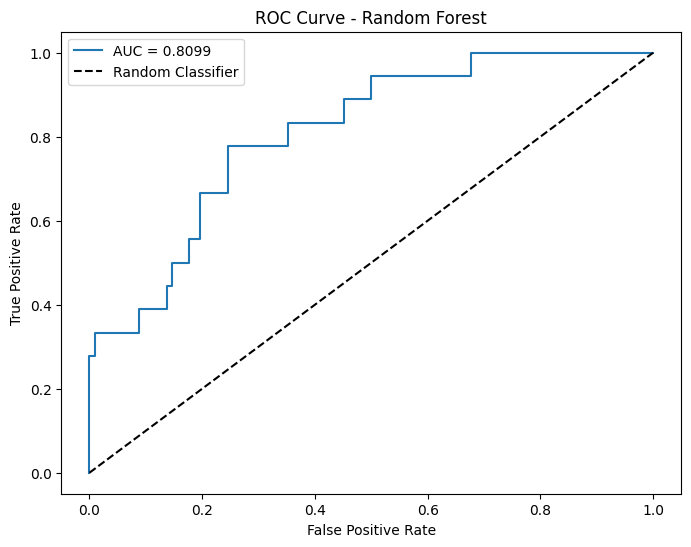

AUC: 0.8099


In [19]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

print(f"AUC: {auc:.4f}")

1. What does the ROC curve represent in a classification model? The ROC curve represents
the True Positive Rate (TPR) against the False Positive Rate (FPR) for every classification
threshold.

2. What does the Area Under the Curve (AUC) measure? The AUC summarizes the entire
ROC curve as a percentage; it’s how effectively the model discriminates between a churner
and a non-churner.

3. What does the AUC for this model tell us? An AUC of 0.8099 means the model correctly ranks a churner above a non-churner about 81% of the time. This is an improvement over the Decision Tree model from the previous assignment, which scored 0.77, suggesting that averaging many trees produces better discrimination between the two groups.

4. What would an AUC value close to 1.00 imply? This would be an ideal model. It would
almost identifify all churn probabilities rathern than identifying non-churners as churners.
This means the model can clearly distinguish the two groups at the specified threshold.

5. Why is ROC analysis useful when classification thresholds can change? The ROC analysis
lets us evaluate the model’s overall performance and quality before setting a threshold aligned
with the company’s priorities. The ROC curve is especially valuable here, given that the default threshold produced zero churn predictions.

**Part 5: Feature Importance Using an AI Assistant**

                               Feature  Importance
4              remainder__TenureMonths    0.475850
5             remainder__MonthlyCharge    0.277074
6              remainder__SupportCalls    0.120415
3  cat__PaymentMethod_Electronic Check    0.035614
2       cat__PaymentMethod_Credit Card    0.035056
1           cat__ContractType_Two-Year    0.031949
0           cat__ContractType_One-Year    0.024041


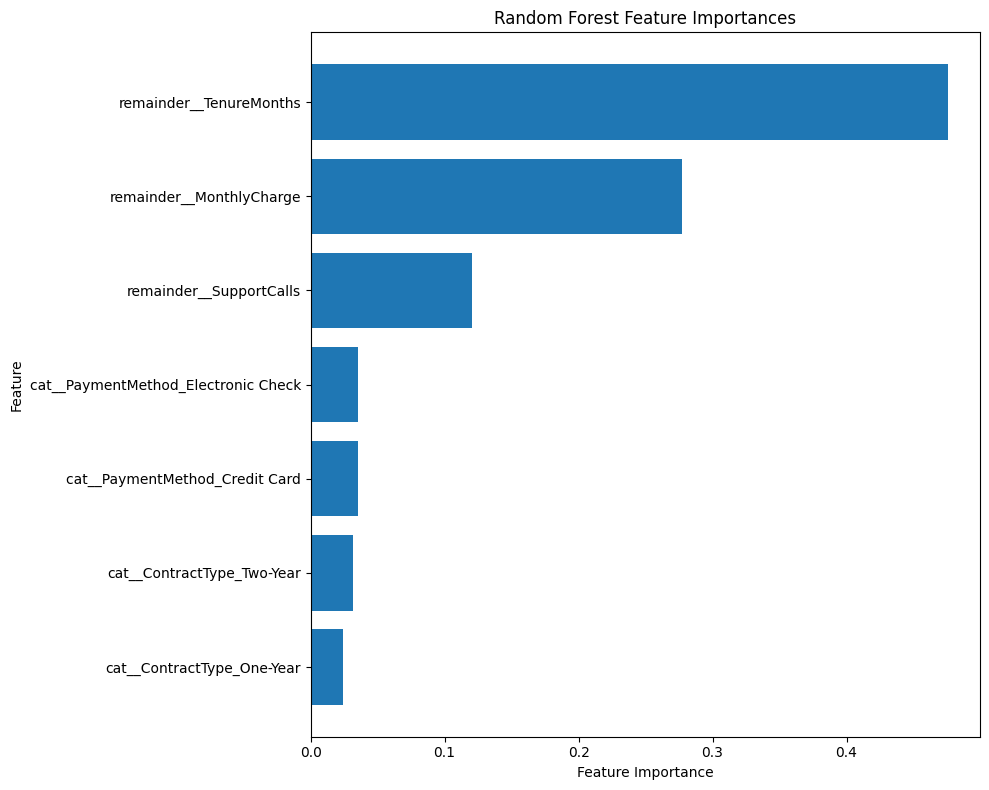

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract fitted components
preprocessor = pipeline.named_steps['preprocessor']
classifier = pipeline.named_steps['classifier']

# Get feature names after preprocessing
feature_names = preprocessor.get_feature_names_out()

# Get feature importances from Random Forest
importances = classifier.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance (highest first)
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display ranked features
print(feature_importance_df)

# Plot sorted horizontal bar chart
plt.figure(figsize=(10, 8))
plt.barh(
    feature_importance_df['Feature'],
    feature_importance_df['Importance']
)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importances')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

The features that matter the most are TenureMonths (0.476), MonthlyCharge (0.277), and SupportCalls (0.120). TenureMonths being the single biggest driver (0.476) aligns with the idea that loyalty is the strongest predictor of staying.

The results do show bias towards Continuous features. Continuous features give the model many more possible split points. TenureMonths could split at 5, 10, 15, 20 months, etc. But a one-hot-encoded column like ContractType_One-Year is either 0 or 1.  There's only one possible split point, so it has far fewer chances to reduce impurity across all 300 trees.

**Part 6: Reduced-Feature Model**

In [21]:
X_reduced = df[['TenureMonths', 'MonthlyCharge', 'SupportCalls']]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42
)

In [22]:
pipeline_reduced = Pipeline(steps=[
    ('classifier', RandomForestClassifier(n_estimators=300, max_depth=12,
                                           min_samples_leaf=18, random_state=42))
])

pipeline_reduced.fit(X_train_r, y_train_r)

Pipeline(steps=[('classifier',
                 RandomForestClassifier(max_depth=12, min_samples_leaf=18,
                                        n_estimators=300, random_state=42))])

In [23]:
y_pred_r = pipeline_reduced.predict(X_test_r)

cm_r = confusion_matrix(y_test_r, y_pred_r)
print("Confusion Matrix (Reduced):")
print(cm_r)

accuracy_r = accuracy_score(y_test_r, y_pred_r)
precision_r = precision_score(y_test_r, y_pred_r, zero_division=0)
recall_r = recall_score(y_test_r, y_pred_r)

print(f"Accuracy: {accuracy_r:.4f}")
print(f"Precision: {precision_r:.4f}")
print(f"Recall: {recall_r:.4f}")

Confusion Matrix (Reduced):
[[102   0]
 [ 18   0]]
Accuracy: 0.8500
Precision: 0.0000
Recall: 0.0000


Which metric changed the most? None of the metrics changed.


Did any metric decrease? No, all metrics remained the same.


Would you deploy the full model or the reduced-feature model in practice — and why? I would deploy the reduced model since both models performed equally. Deploying the reduced model is simpler, requires less data to collect, and makes it easier to brief stakeholders.

